# Глава 2. От октября к ноябрю: проверка исходных рядов

**LEO West · W_R4_C-4 · D1/D2/D3 · ноябрь 2017**  
Dimitri Bolt · 25.09.2026 · **Среднее и отклонения за 16 ноября рассчитаны; фазы предстоят**

[Оглавление](README.md) · [Назад: глава 1](01_october_2017.ipynb) · [Подробные проверки](details/02_data_checks.md)

**Цель главы:** проверить, сохраняются ли октябрьские амплитуды и фазовые сдвиги
$A_j(W),\phi_j(W),\Delta_{jk}(W)$ в ноябре. Первый шаг выявил особенности записей,
которые надо учесть до подгонки модели.

## 2.1. Ноябрьские данные

Интервал **[01.11.2017, 01.12.2017)**, местное время базы. Те же датчики
**994 / 1010 / 1026**; по **10 582 записи** на каждый, всего **31 746**.
Кодов ошибки $\leq -9999$ нет. Все исходные значения, повторы и временные метки сохранены.

[Данные и происхождение](data/ch02/README.md) · [Код и запуск](details/02_data_checks.md#запуск-и-следующий-шаг)

In [1]:
from pathlib import Path
import importlib
import sys
project = next(p for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "Project_description/Research_log/chapter02.py").is_file())
if str(project) not in sys.path:
    sys.path.insert(0, str(project))
from Project_description.Research_log import chapter02
# Перечитать обновлённый модуль и создать новый report в текущем ядре.
report = importlib.reload(chapter02).load_november()

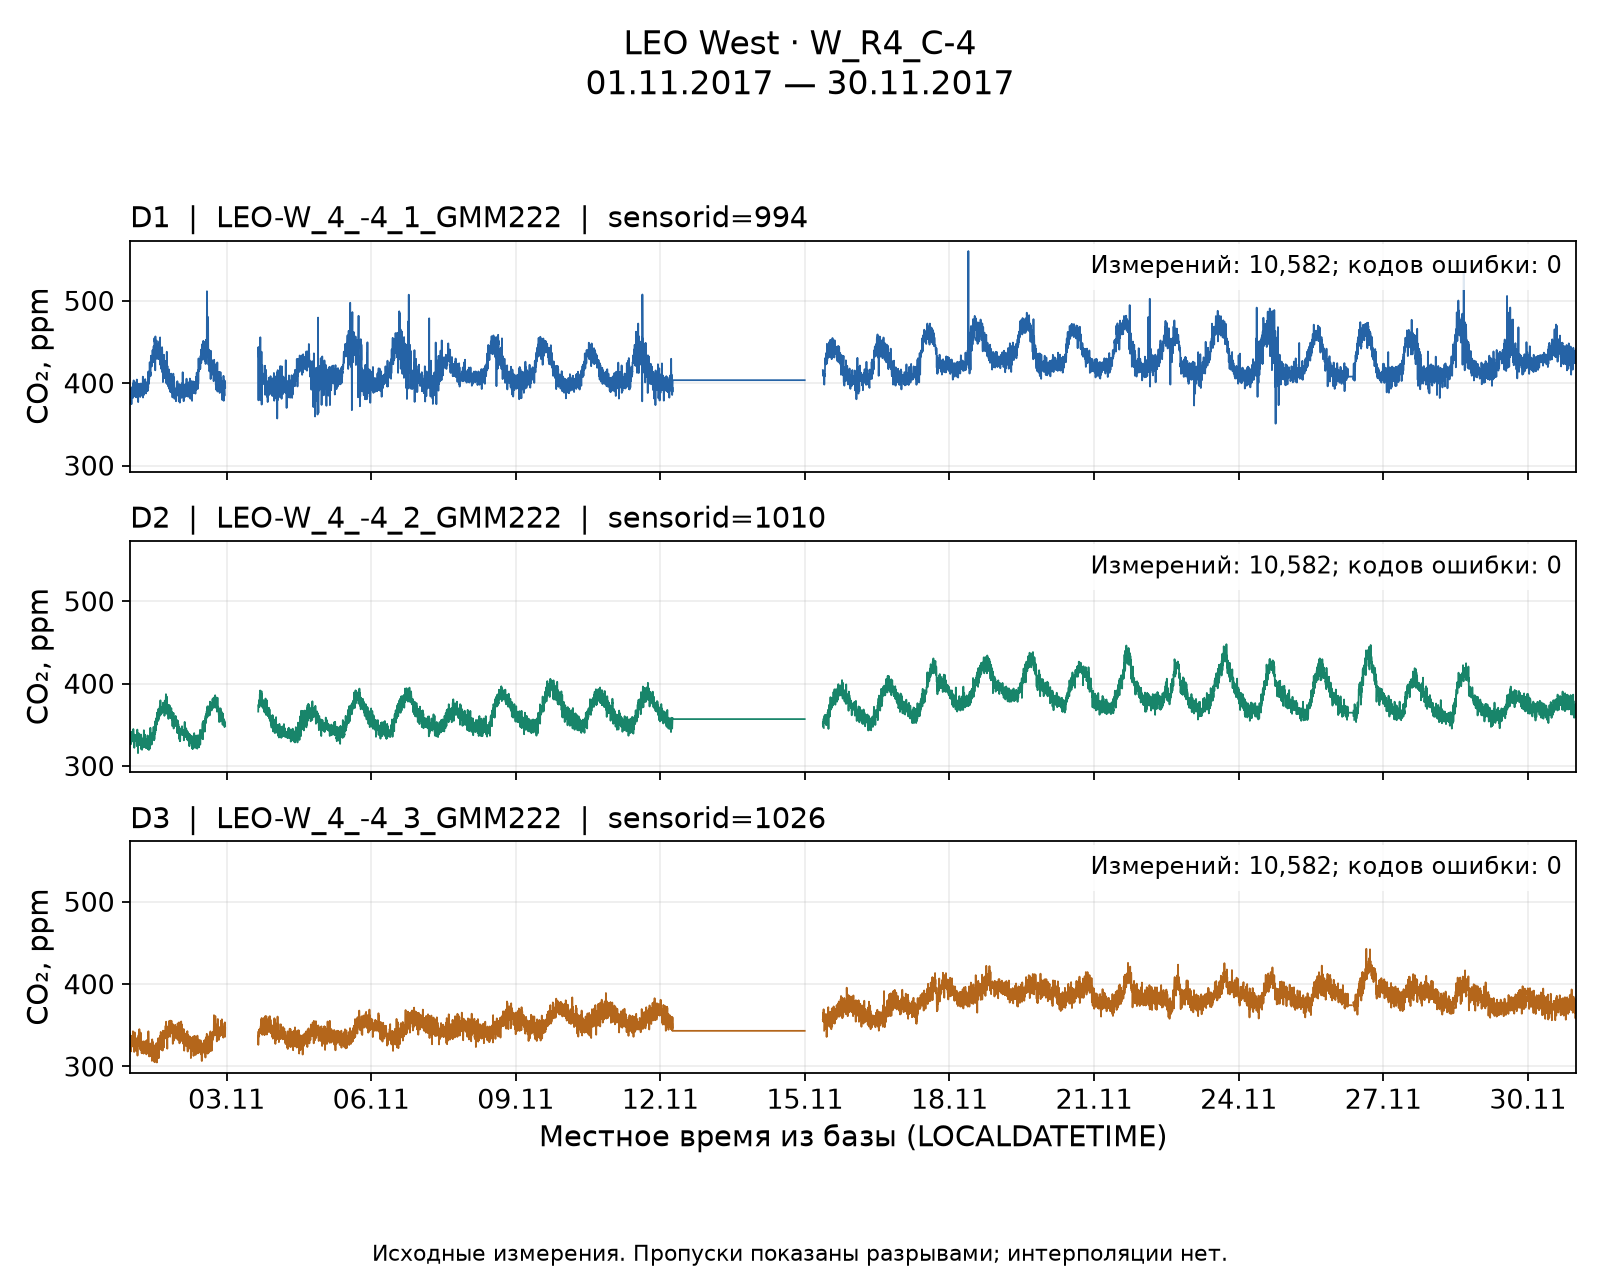

In [2]:
report.show("raw")

**Рисунок 2.1.** Три исходных ряда на общей временной шкале. Пропуски разрывают линию;
прямой участок 12–14 ноября состоит из реально записанных постоянных значений.
Интерполяция не выполнялась.

## 2.2. Неравномерное число записей

В каждом ряду есть **2262 интервала длиной 0–10 секунд** между соседними записями;
медиана положительного шага — **299 секунд**. В октябрьском снимке интервалов 0–10 секунд не было.
С 7 по 14 ноября число записей достигает 514–533 в сутки, 30 ноября — 519.
Более частые записи при одинаковых весах сильнее влияют на среднее и МНК.

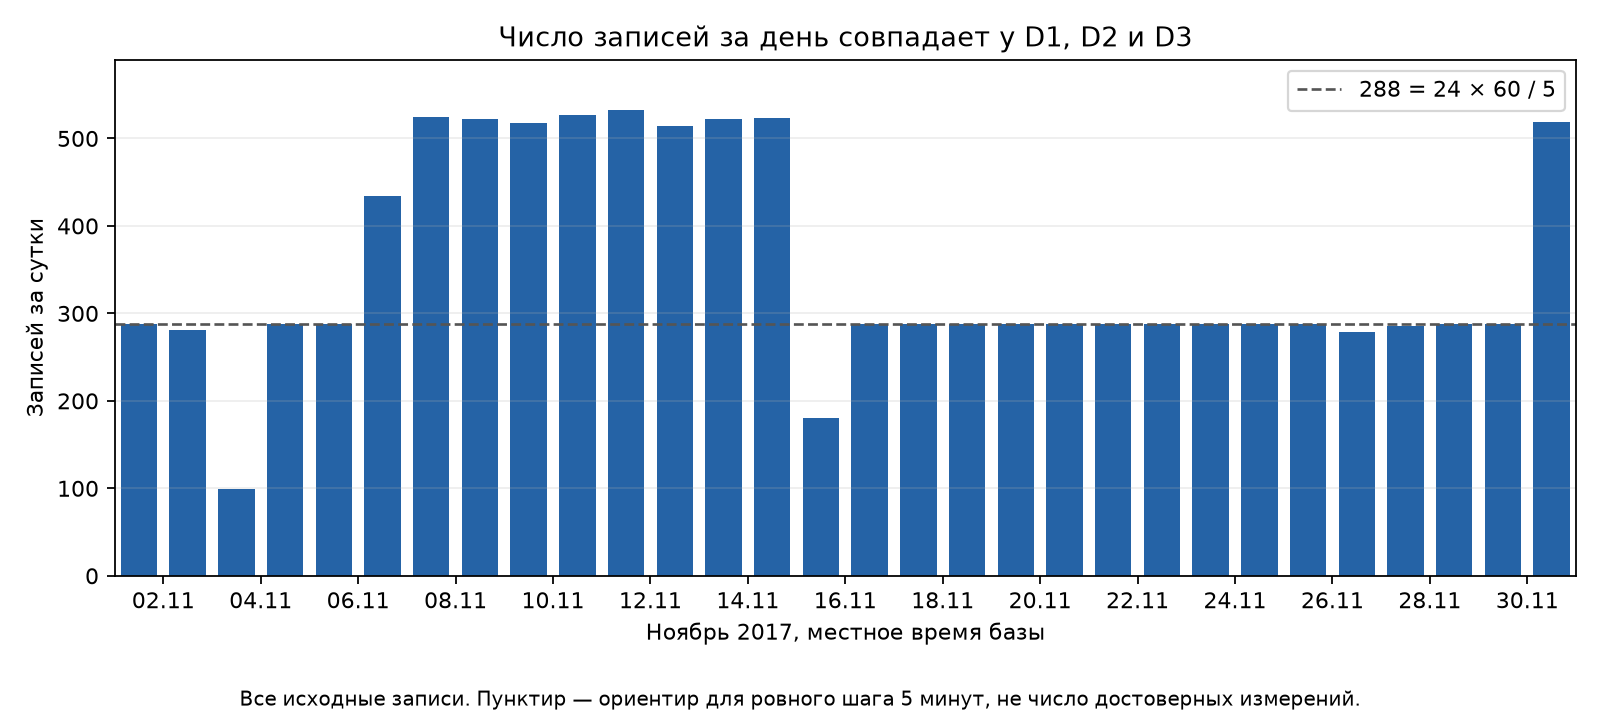

In [3]:
report.show("counts")

**Рисунок 2.2.** Суточное число записей одинаково у трёх датчиков.
Пунктир $288=24\cdot60/5$ — ориентир для равномерного шага 5 минут.
Увеличение числа строк само по себе не означает увеличение количества независимой информации.

[Подробно о шаге и пропусках](details/02_data_checks.md#шаг-и-число-записей)

## 2.3. Залипание датчиков

**Правило обработки:** выявленные длительные участки неизменных показаний считаю
периодами неработоспособности и исключаю из последующего анализа.

У D1/D2/D3 совпадают два таких интервала:

- **12.11.2017 06:10:04 — 14.11.2017 23:55:08:** 65,75 часа, по 1435 записей
  на датчик. Значения D1/D2/D3: **403,657 / 356,967 / 343,271 ppm**.
- **26.11.2017 06:25:05 — 26.11.2017 08:25:03:** около 2 часов,
  по 25 записей на датчик.

Каждый датчик повторяет своё значение. Исходные записи сохраняю;
в рабочих рядах на этих участках оставляю пропуски.
[Границы участков и метод обнаружения](details/02_data_checks.md#постоянные-участки).

> **Примечание для обсуждения с I.G.** В базе есть повторные временные метки,
> иногда с разными значениями CO₂. Способ их обработки пока не выбран.
> [Подробности](details/02_data_checks.md#повторные-временные-метки).

## 2.4. Результат исключения залипаний

Сопоставляю каждый исходный ряд с рабочим рядом после исключения двух интервалов.
Показываю их на одинаковых шкалах времени и концентрации.

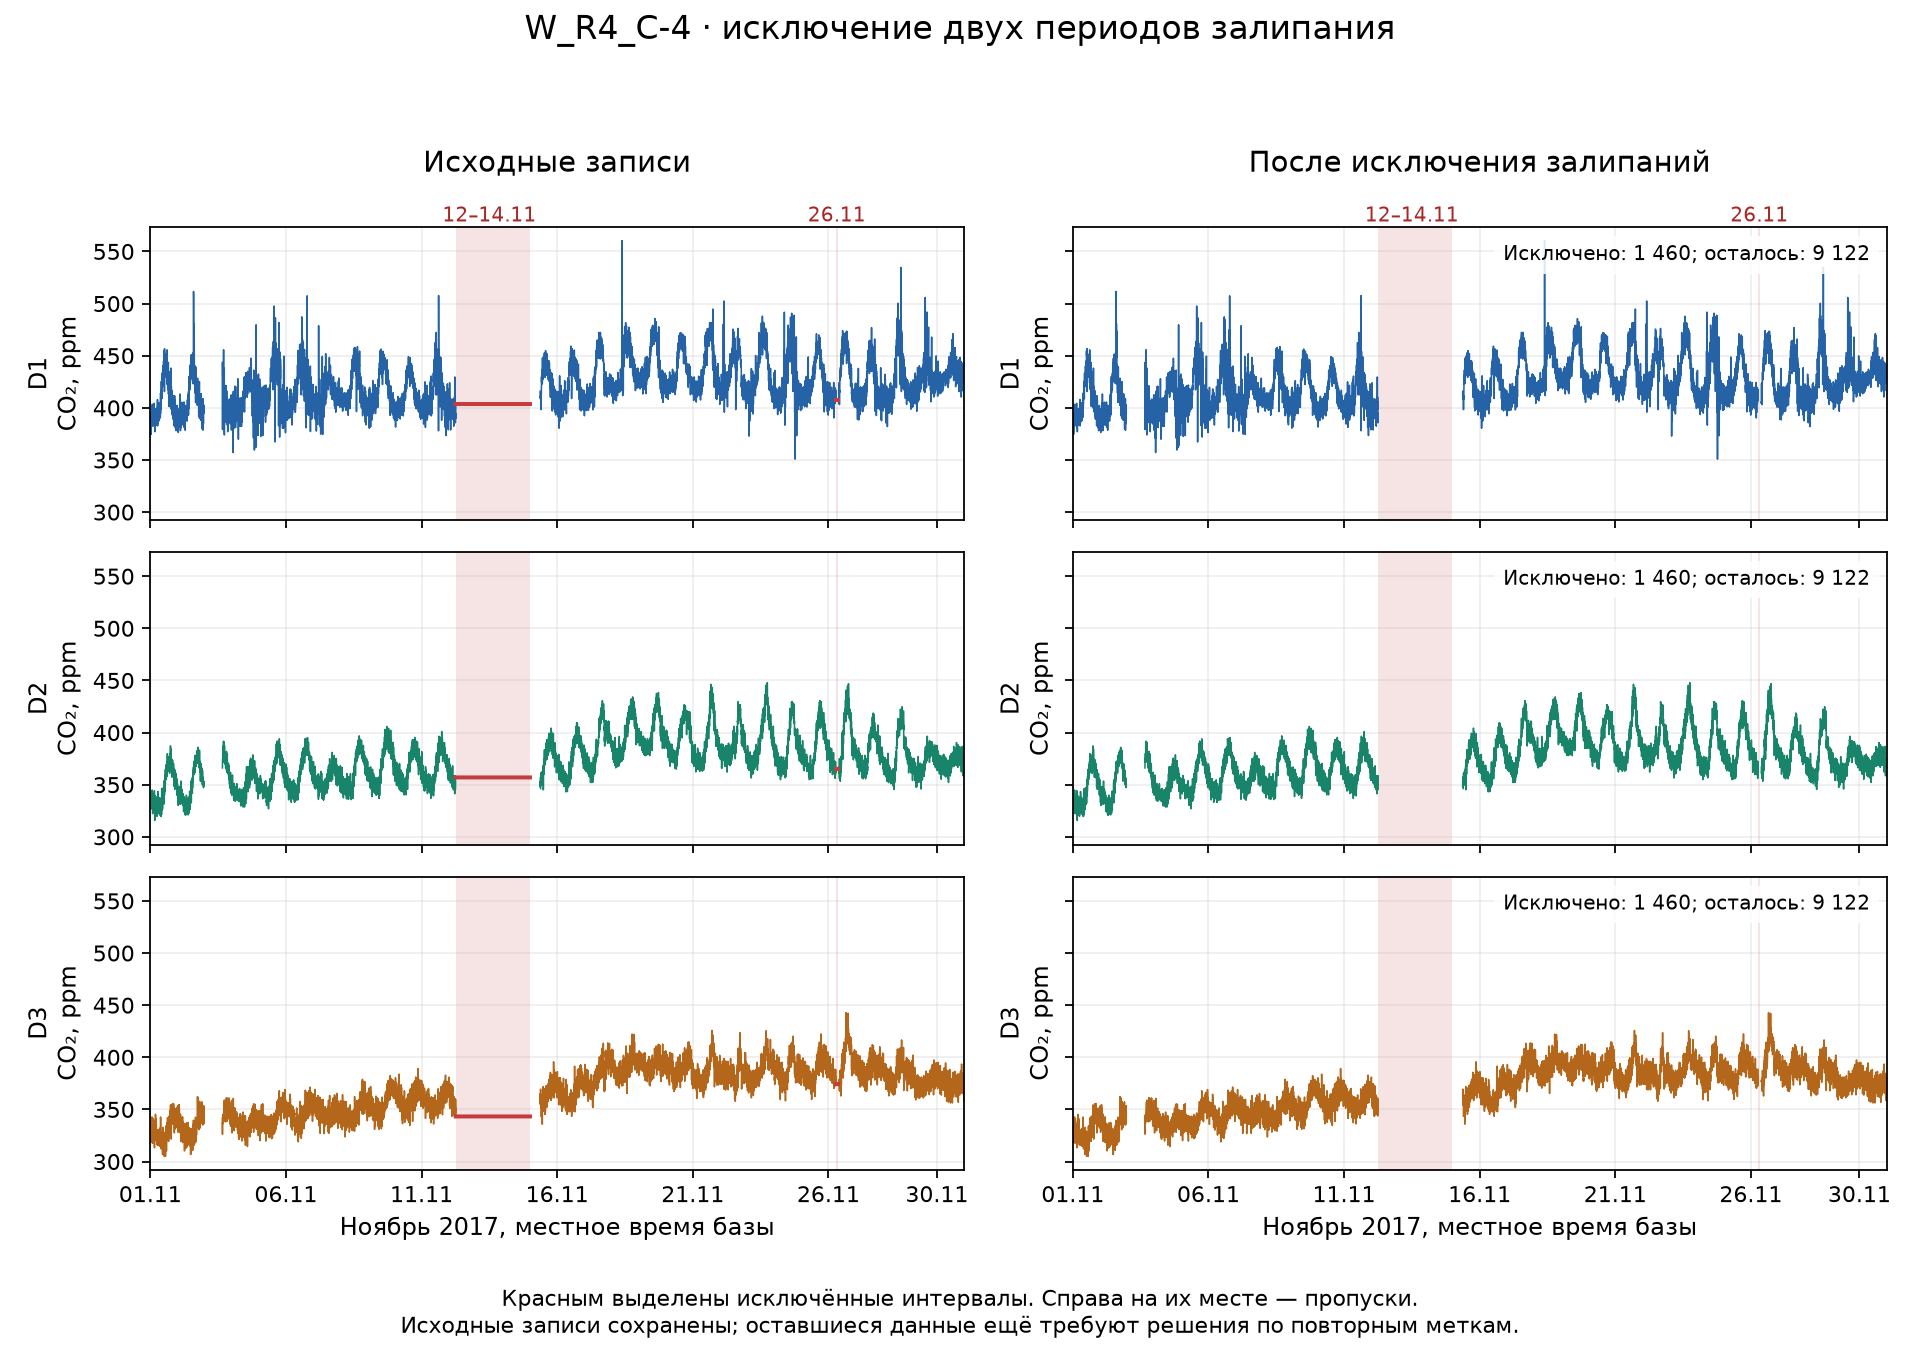

In [4]:
report.show("stuck")

**Рисунок 2.3.** Строки — D1, D2, D3. Слева — исходные записи, справа — ряды
после исключения залипаний. Красным выделены интервалы 12–14 и 26 ноября;
справа на их месте линия прерывается. Двухчасовой участок 26 ноября на масштабе
месяца выглядит как узкая полоска.

На каждом датчике исключил **1460 записей**; осталось **9122 из 10 582**.
Исключённые значения не заменяю нулями и не восстанавливаю интерполяцией.
Все остальные записи сохранены, включая повторы, для которых правило ещё предстоит выбрать.

## 2.5. Для каких суток хватает данных

Проверяю полные сутки одновременно у D1, D2 и D3. Для прежнего суточного среднего
нужны данные в окне $[t-12\,\mathrm{h},\ t+12\,\mathrm{h})$ вокруг каждого момента $t$.
Поэтому отдельно отмечаю наличие самих записей и наличие полного окружающего окна.

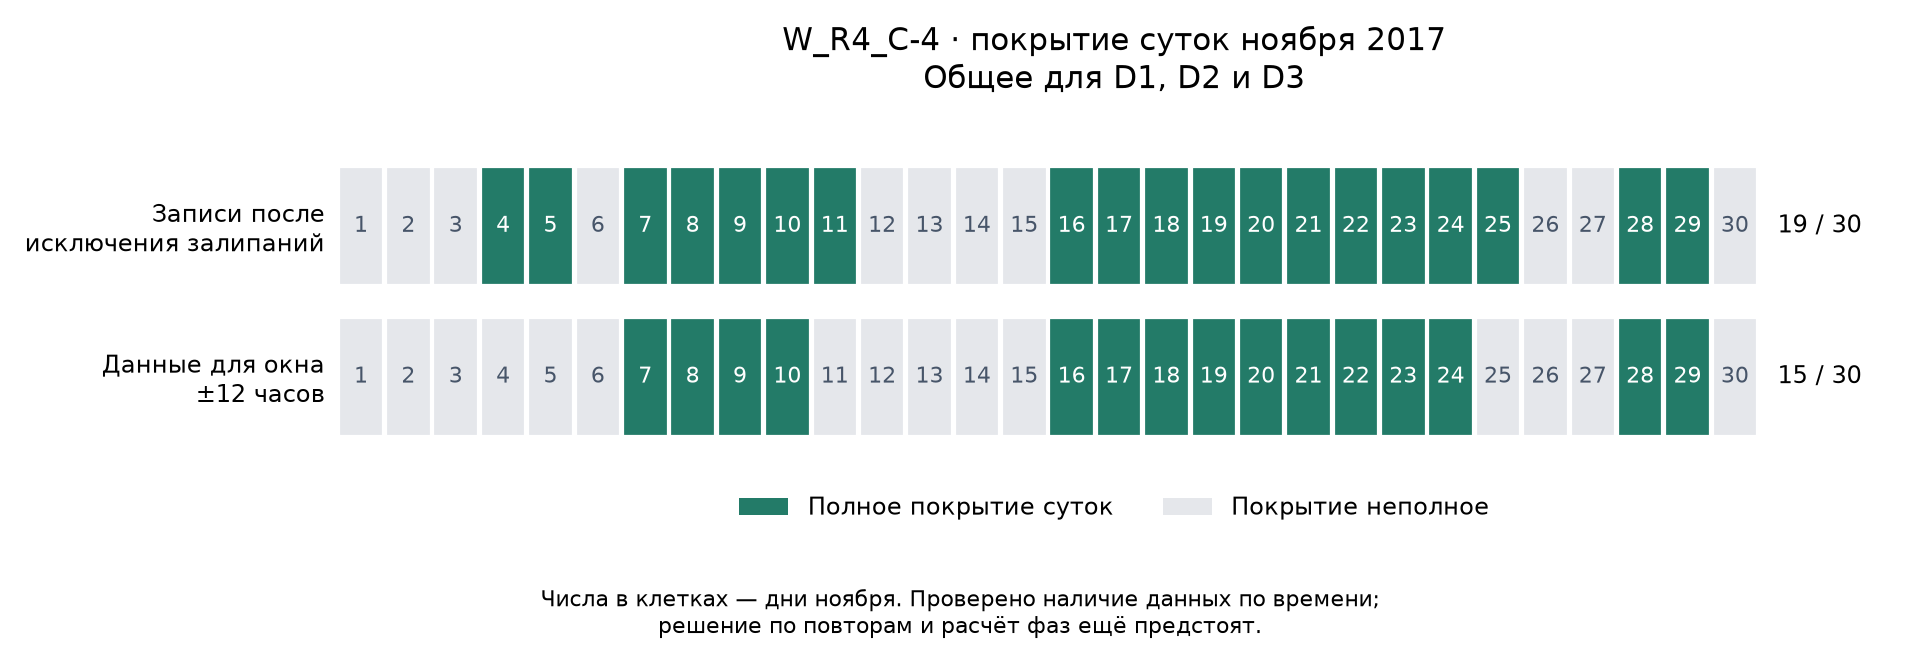

In [5]:
report.show("coverage")

**Рисунок 2.4.** Числа — дни ноября. Зелёным отмечены сутки с полным покрытием
по времени у всех трёх датчиков, серым — с неполным.
Верхняя строка проверяет оставшиеся записи: **19 суток**.
Нижняя учитывает ещё окно ±12 часов: **15 суток — 7–10, 16–24, 28–29 ноября**.

Например, **11 ноября** записи есть весь день, но для позднего вечера уже не хватает
следующих 12 часов из-за залипания 12 ноября. Поэтому сверху клетка зелёная,
а снизу серая. Серый цвет не означает неработоспособность датчика весь день.

**Получено на этом шаге:** 15 суток с полным покрытием по времени для прежней
обработки. Отдельный пример 16 ноября рассматриваю ниже.

[Подробно о календаре](details/02_data_checks.md#day-coverage)

## 2.6. Один день: среднее и отклонения

Беру **16 ноября**, по **288 показаний D1/D2/D3**. Для среднего в окне ±12 часов
использую окружающие данные 15–17 ноября; в этом контексте повторных меток нет.
Из каждого показания вычитаю его окружающее среднее:

$$
r_j(t)=C_j(t)-m_j(t),\qquad j\in\{D1,D2,D3\}.
$$

Здесь $m_j(t)$ — среднее за 24 часа вокруг момента $t$.

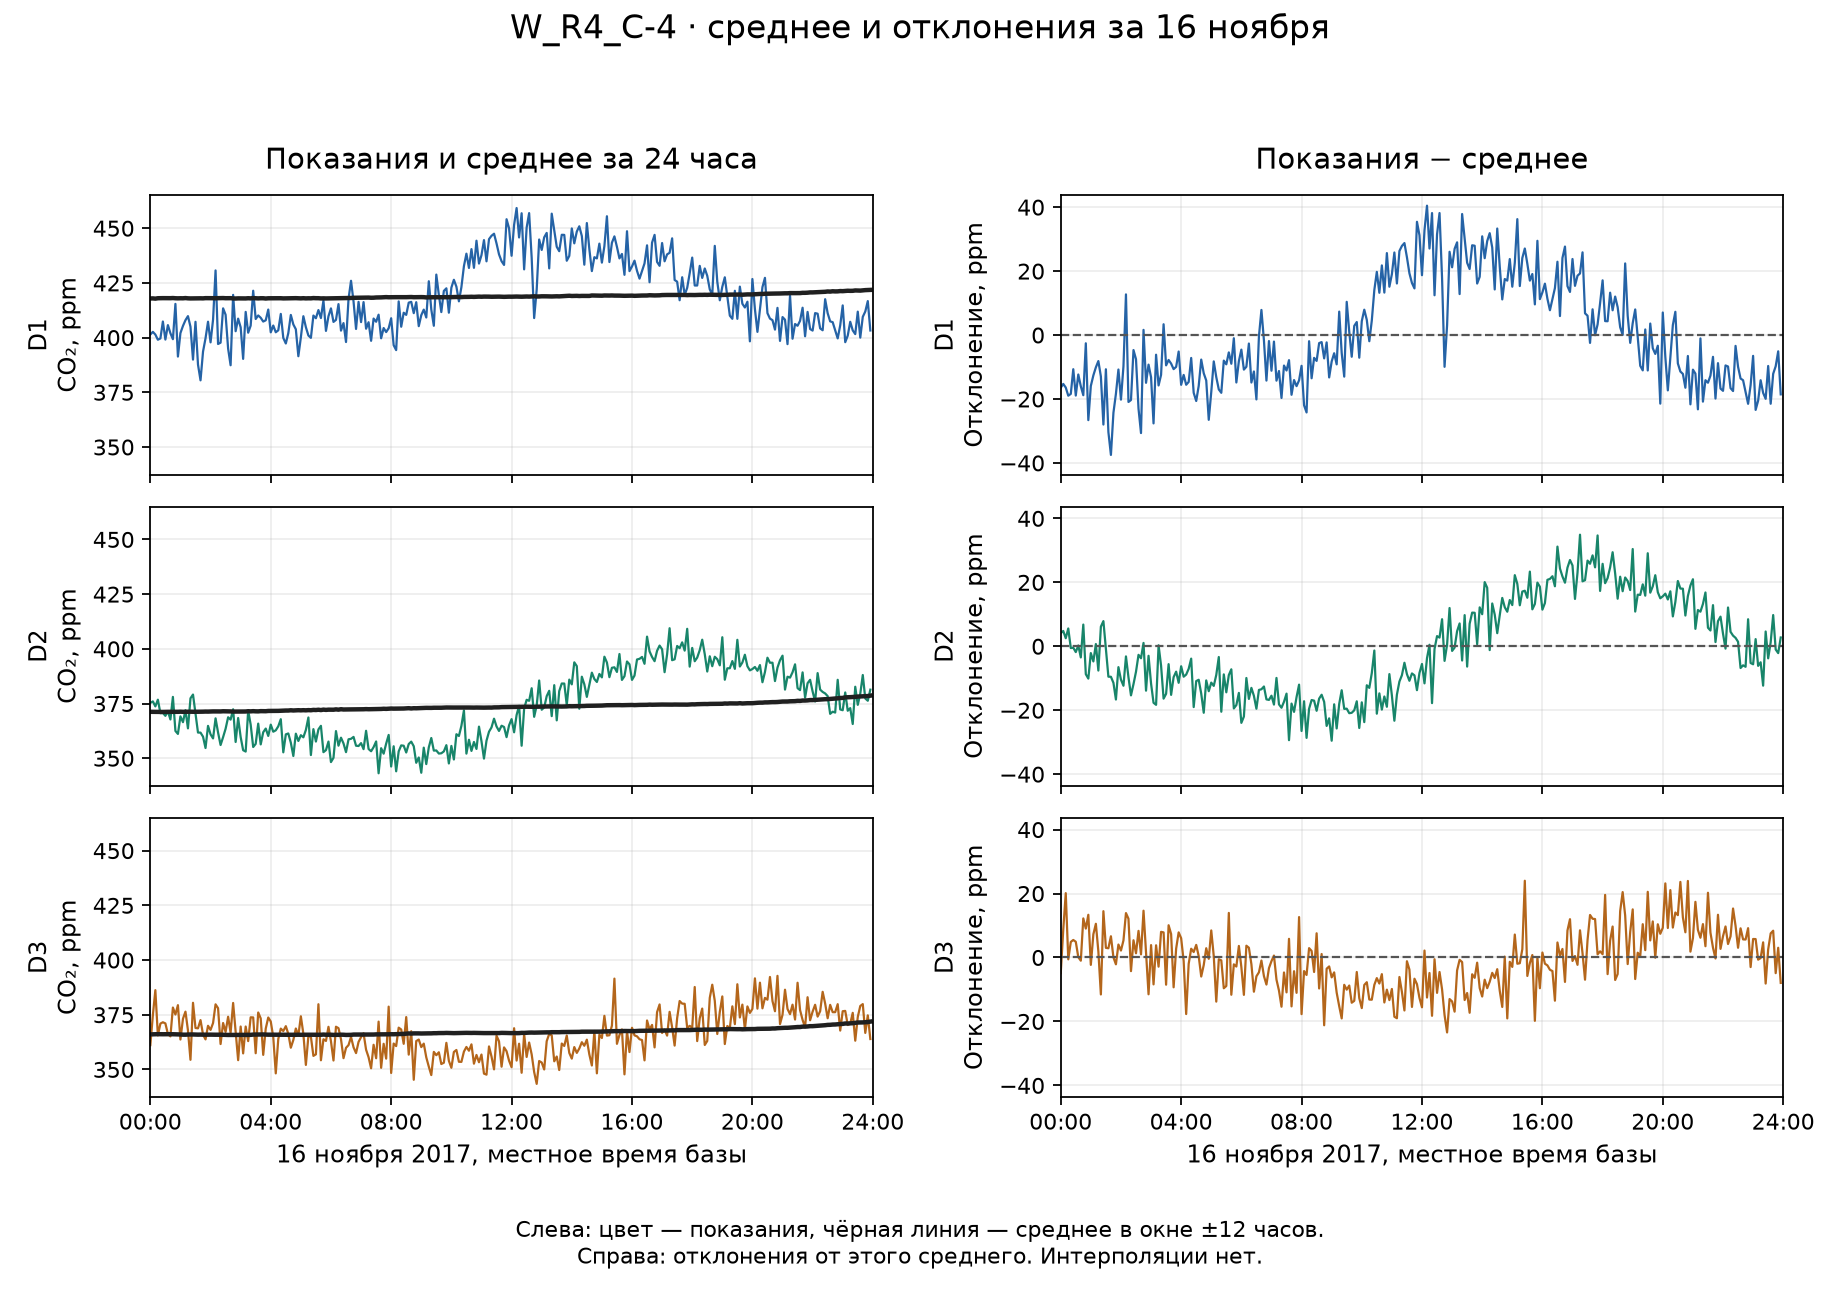

In [6]:
report.show("example_trend")

**Рисунок 2.5.** Строки — D1, D2, D3. Слева цветом показаны исходные концентрации,
чёрным — среднее в окне ±12 часов. Справа — отклонения от этого среднего;
пунктир соответствует нулю. Шкалы одинаковы внутри каждого столбца.

**Получено:** среднее и отклонения для всех **288 точек каждого датчика**, всего
**864 точки**. Теперь сравниваю изменения относительно собственного среднего уровня
каждого датчика. В остатках видны различия формы и положения подъёмов;
быстрые колебания сохранены.

**Далее:** опишу остатки этого дня одной 24-часовой гармоникой. На этом шаге
её амплитуды, R² и фазовые сдвиги ещё не вычислялись.

[Подробности расчёта](details/02_data_checks.md#november-16-trend) ·
[Оглавление](README.md) · [Глава 1](01_october_2017.ipynb) · [Дальнейший план](PLAN.md#chapter-2)